# Prediction of skipass prices in European ski resorts using regression methods

## Comparison of Linear, Ridge and LASSO regression methods using multicollinear predictors


The purpose of the project is to create a model predicting skipass prices in European ski resorts based on the resort's characteristics, such as e.g. highest point altitude, length of ski slopes, number of lifts and its location. 
A large subset of predictor variables exhibits multicollinearity, which violates the assumptions of valid OLS model estimation. Therefore, in addition to classical OLS method, regularization methods (such as Ridge and LASSO) were used, as they allow for estimation in the presence of multicollinear predictors. Results obtained using these methods were then compared and the final best-performing model was selected and interpreted. 

Data used in the project comes from the Kaggle website and involves information gathered from ski-resort-stats.com website in February 2022. Link to the dataset: https://www.kaggle.com/datasets/thomasnibb/european-ski-resorts/data. 

# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.linear_model import RidgeCV, LassoCV
import shap

# 2. Data - initial exploration of the dataset

In [2]:
df=pd.read_csv('European_Ski_Resorts.csv')

In [3]:
'''path = kagglehub.dataset_download(
    "thomasnibb/european-ski-resorts"
)

df = pd.read_csv(os.path.join(path, "European_Ski_Resorts.csv"))'''

'path = kagglehub.dataset_download(\n    "thomasnibb/european-ski-resorts"\n)\n\ndf = pd.read_csv(os.path.join(path, "European_Ski_Resorts.csv"))'

In [4]:
df.drop('Unnamed: 0',axis=1, inplace=True)

## 2.1. Basic information about the dataset

In [5]:
df.shape

(376, 17)

Dataset contains data on 376 ski resorts, using 17 variables. 

In [6]:
df.head(5)

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
0,Alpendorf (Ski amedé),Austria,1980,740,52,30,81,4,115,Yes,No,22,16,11,49,75398,600
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47,100,77,33,210,Yes,Yes,37,28,7,72,99017,1032
2,Oberau (Wildschönau),Austria,1130,900,30,1,0,1,2,No,No,2,0,0,2,1932,0
3,Dachstein West,Austria,1620,780,42,15,33,3,51,Yes,Yes,25,8,3,36,32938,163
4,Rosa Khutor,Southern Russia,2320,940,22,30,26,21,77,Yes,No,6,11,10,27,49228,450


In [7]:
df.columns

Index(['Resort', 'Country', 'HighestPoint', 'LowestPoint', 'DayPassPriceAdult',
       'BeginnerSlope', 'IntermediateSlope', 'DifficultSlope', 'TotalSlope',
       'Snowparks', 'NightSki', 'SurfaceLifts', 'ChairLifts', 'GondolaLifts',
       'TotalLifts', 'LiftCapacity', 'SnowCannons'],
      dtype='object')

Dataset consists of the following variables: 
* **DayPassPriceAdult - one-day adult skipass price in the main season, in euros,**
* Resort - resort name,
* Country - country, in which the resort is located,
* HighestPoint - highest point altitude in meters,
* LowestPoint - lowest point altitude in meters,
* BeginnerSlope - overall length of beginner slopes in kilometers,
* IntermediateSlope - overall length of intermediate slopes in kilometers,
* DifficultSlope - overall length of difficult slopes in kilometers,
* TotalSlope - total length of slopes in the resort in kilometers (= BeginnerSlope + IntermediateSlope + DifficultSlope)
* Snowparks - binary variable, if the resort offers snowparks,
* NightSki - binary variable, if the resort offers night-skiing,
* SurfaceLifts - number of surface ski lifts,
* ChairLifts - number of chair ski lifts, 
* GondolaLifts - number of gondola ski lifts, 
* TotalLifts - total number of ski lifts in the resort (= SurfaceLifts + ChairLifts + GondolaLifts),
* LiftCapacity - lifts capacity per hour,
* SnowCannons - number of snow cannons in the resort.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Resort             376 non-null    object
 1   Country            376 non-null    object
 2   HighestPoint       376 non-null    int64 
 3   LowestPoint        376 non-null    int64 
 4   DayPassPriceAdult  376 non-null    int64 
 5   BeginnerSlope      376 non-null    int64 
 6   IntermediateSlope  376 non-null    int64 
 7   DifficultSlope     376 non-null    int64 
 8   TotalSlope         376 non-null    int64 
 9   Snowparks          376 non-null    object
 10  NightSki           376 non-null    object
 11  SurfaceLifts       376 non-null    int64 
 12  ChairLifts         376 non-null    int64 
 13  GondolaLifts       376 non-null    int64 
 14  TotalLifts         376 non-null    int64 
 15  LiftCapacity       376 non-null    int64 
 16  SnowCannons        376 non-null    int64 
dt

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighestPoint,376.0,2051.688830,776.719908,0.0,1550.00,2104.0,2567.50,3899.0
LowestPoint,376.0,1055.098404,423.604310,0.0,779.25,1050.0,1350.00,2180.0
DayPassPriceAdult,376.0,40.779255,12.474259,0.0,34.00,42.0,49.00,81.0
BeginnerSlope,376.0,35.869681,53.719832,0.0,8.00,19.0,40.00,312.0
IntermediateSlope,376.0,38.348404,49.691136,0.0,9.00,22.0,42.25,239.0
DifficultSlope,376.0,11.776596,17.785780,0.0,2.00,5.0,13.00,103.0
TotalSlope,376.0,86.257979,113.740218,0.0,25.00,48.0,100.00,600.0
SurfaceLifts,376.0,13.662234,14.438661,0.0,5.00,9.0,17.00,89.0
ChairLifts,376.0,9.340426,12.595282,0.0,2.00,5.0,10.00,74.0
GondolaLifts,376.0,3.954787,6.565411,0.0,0.00,2.0,5.00,40.0


Each variable has a minimum value equaling 0, which indicates a presence of invalid records in the dataset. It was decided to eliminate observations for which at least one of the variables *DayPassPriceAdult*, *TotalSlope*, *TotalLifts* and *LiftCapacity* equal 0 or all variables *BeginnerSlope*, *IntermediateSlope* and *DifficultSlope*  simultaneously equal 0. After that operation the descriptive statistic should be verified again. 

In [10]:
df.sort_values(by='HighestPoint', ascending=True).head(3)

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
220,Copenhagen (planned),Denmark,0,0,0,0,0,0,0,no report,No,0,0,0,0,0,0
219,Dry slopes Ski Arena – Aarhus,Denmark,23,20,0,0,0,0,0,no report,No,0,0,0,0,0,0
222,Hoch Hylkedal – Kolding,Denmark,45,20,15,0,0,0,0,no report,No,0,0,0,0,600,0


Checking the number of invalid records

In [11]:
print("DayPassPriceAdult = 0 :",(df['DayPassPriceAdult']==0).sum())
print("TotalSlope = 0 :",(df['TotalSlope']==0).sum())
print("TotalLifts = 0 :",(df['TotalLifts']==0).sum())
print("LiftCapacity = 0 :",(df['LiftCapacity']==0).sum())
print("Sum of slope lengths = 0 :",((df['BeginnerSlope']==0)&(df['IntermediateSlope']==0)&(df['DifficultSlope']==0)).sum())

DayPassPriceAdult = 0 : 8
TotalSlope = 0 : 11
TotalLifts = 0 : 8
LiftCapacity = 0 : 6
Sum of slope lengths = 0 : 14


Dropping the invalid records

In [12]:
df = df[(df['DayPassPriceAdult']!=0)&(df['TotalSlope']!=0)&(df['TotalLifts']!=0)&(df['LiftCapacity']!=0)&((df['BeginnerSlope']!=0)|(df['IntermediateSlope']!=0)|(df['DifficultSlope']!=0))]

## 2.2. Checking for missing values and duplicates

In [ ]:
df.isna().sum()

Resort               0
Country              0
HighestPoint         0
LowestPoint          0
DayPassPriceAdult    0
BeginnerSlope        0
IntermediateSlope    0
DifficultSlope       0
TotalSlope           0
Snowparks            0
NightSki             0
SurfaceLifts         0
ChairLifts           0
GondolaLifts         0
TotalLifts           0
LiftCapacity         0
SnowCannons          0
dtype: int64

In [ ]:
print(df.duplicated().sum())

0


There are no missing or duplicated observations in the dataset.

## 2.3. Basic descriptive statistics

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighestPoint,357.0,2106.263305,708.877407,163.0,1608.0,2120.0,2594.0,3899.0
LowestPoint,357.0,1082.703081,392.626894,91.0,803.0,1066.0,1370.0,2180.0
DayPassPriceAdult,357.0,41.882353,10.829768,17.0,34.0,43.0,49.0,81.0
BeginnerSlope,357.0,37.571429,54.567591,0.0,10.0,20.0,42.0,312.0
IntermediateSlope,357.0,40.207283,50.290299,0.0,10.0,23.0,45.0,239.0
DifficultSlope,357.0,12.330532,18.076072,0.0,2.0,6.0,14.0,103.0
TotalSlope,357.0,90.375350,115.215378,1.0,27.0,50.0,100.0,600.0
SurfaceLifts,357.0,14.291317,14.532964,0.0,6.0,9.0,17.0,89.0
ChairLifts,357.0,9.781513,12.766591,0.0,3.0,5.0,11.0,74.0
GondolaLifts,357.0,4.117647,6.683255,0.0,0.0,2.0,5.0,40.0


In [14]:
stats = df.describe(exclude='number').T
stats['freq_percent'] = stats['freq']/stats['count']*100
stats['freq_percent'] = stats['freq_percent'].astype(float).round(2)
stats

,count,unique,top,freq,freq_percent
Resort,357,357,Zauchensee,1,0.28
Country,357,24,Austria,89,24.93
Snowparks,357,2,Yes,275,77.03
NightSki,357,2,No,208,58.26


* The analysis covers 357 ski resorts, located in 24 countries. 89 resorts (25%) are located in Austria. 
* The average price of a one-day skipass is 42 euros, with standard deviation of 11 euros. Prices vary from 17 to 81 euros. 
* 77% of the resorts offer snow parks and 42% of the resorts offer night skiing.
* The highest point altitude in the resorts ranges from 163 m to 3,899 m, with a mean of 2,106 m. At least half of the analyzed resorts have a point at the altitude of 2,120 m.
* The lowest point altitude in the resorts ranges from 91 m to 2,180m, with a mean of 1,083 m. This suggests that the resorts vary significantly in terms of the altitude at which they are located. 
* Not every resort has a slope of each type - there are resorts which do not offer one of the beginner/intermediate/difficult slopes. 
* The average length of slopes in the resort is the biggest for the intermediate slopes (40 km).
* Ski resorts offer an average of 90 km slopes. The total length of the slopes ranges from 1 km to 600 km. 
* The average number of ski lifts is 28, with the highest number of surface lifts (14 surface lifts on average). The mean number of lifts is the lowest for gondola lifts (4 lifts on average). At least 25% of the resorts do not offer any gondola lifts.
* Resorts have the mean capacity of 36,000 people (ranging from 900 to 252,000 people).
* The mean number of snow cannons in the resort equals 230. At leats 25% of the resorts do not own any snow cannons. 

# 3. EDA

## 3.1. Variable distributions

* numerical variables

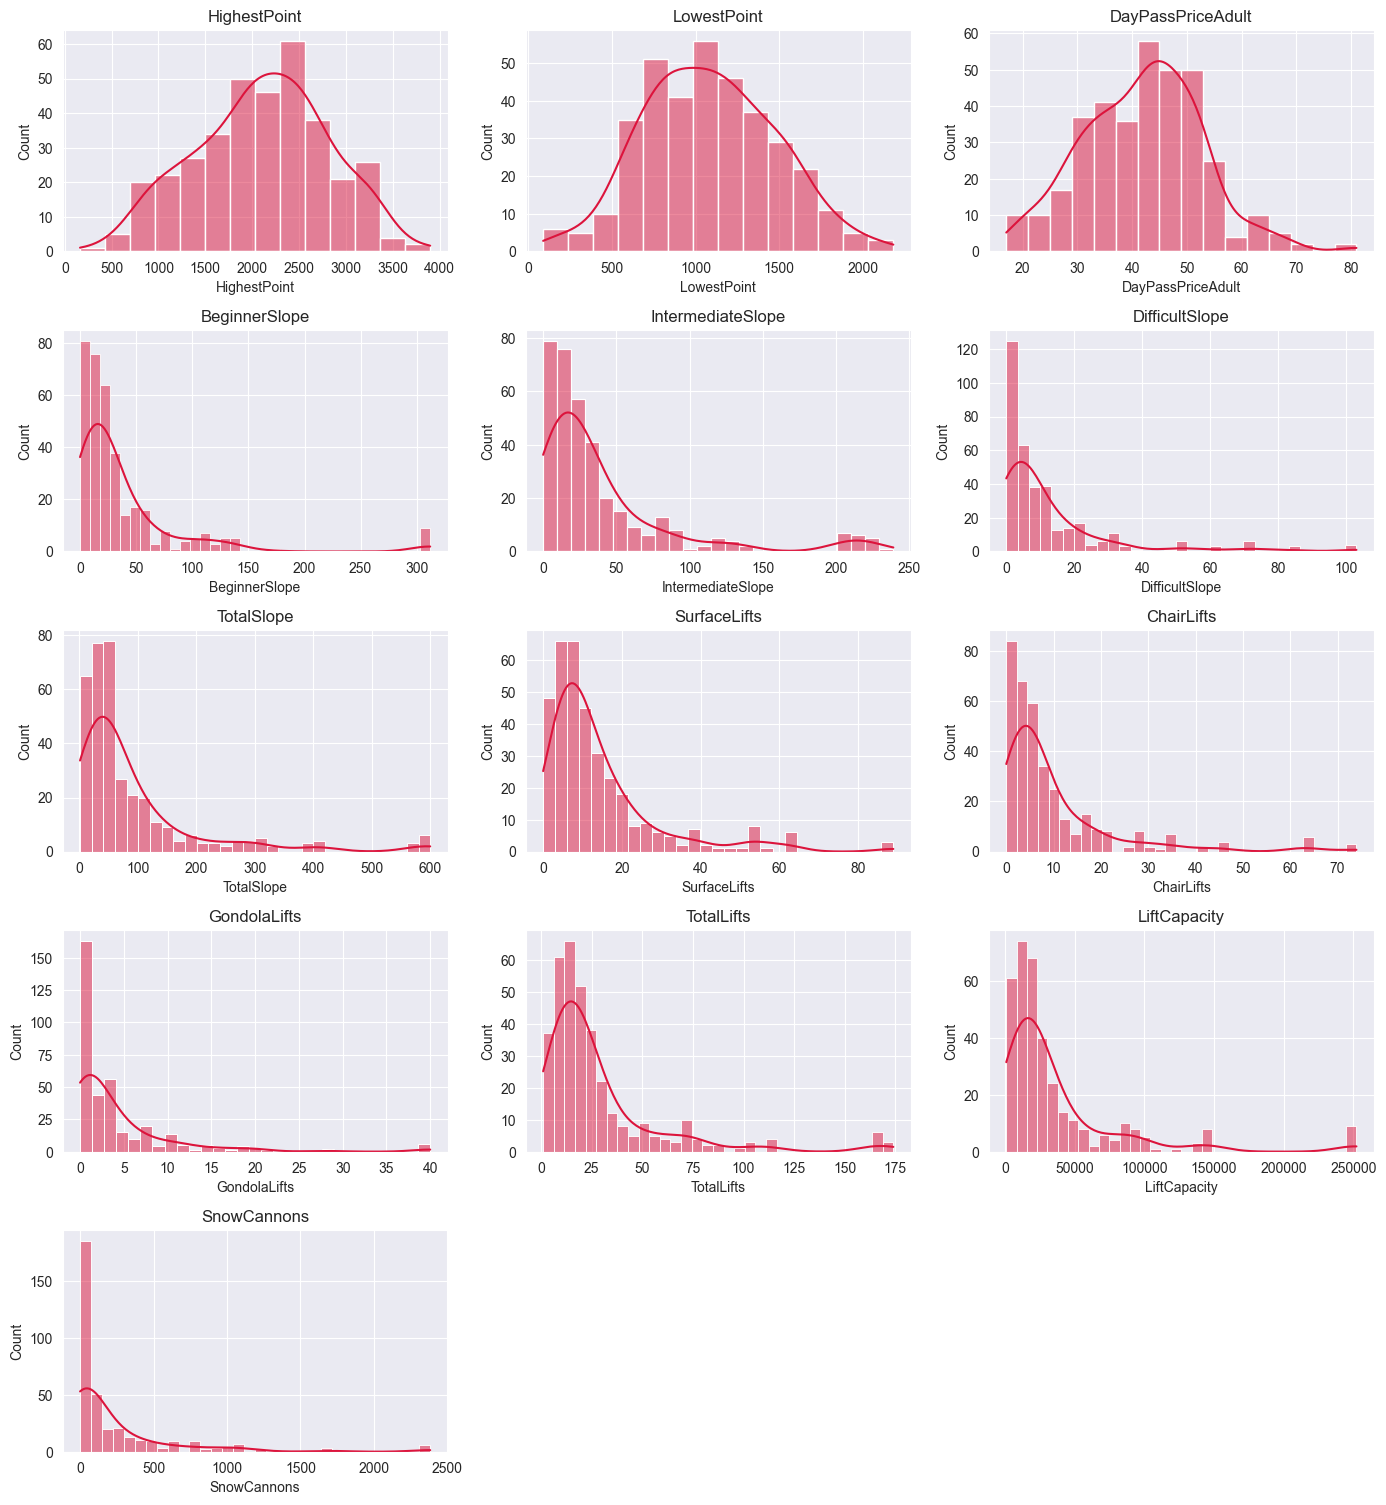

In [17]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=['int64'])

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 3, idx)
    sns.histplot(df[feature], kde=True, color='crimson')
    plt.title(feature)

plt.tight_layout()
plt.show()

Variables *HighestPoint* and *LowestPoint* have approximately symmetric distributions. *DayPassPriceAdult* variable is right-skewed, which indicates some cases of very high skipass prices. 
The rest of the variables are characterized by very strong right skewness, with extreme outliers present.

* binary variables

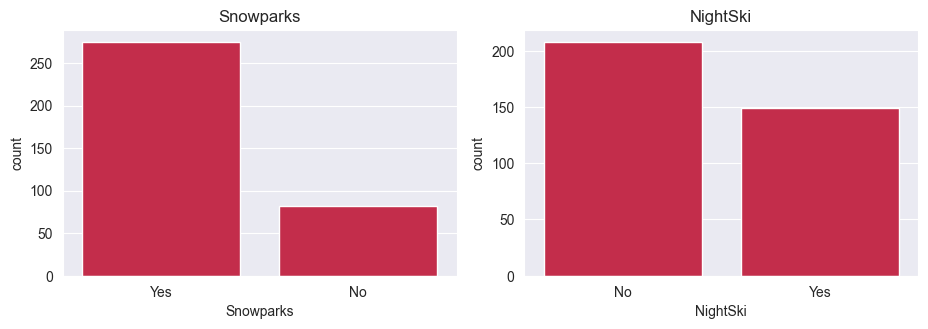

In [18]:
sns.set_style("darkgrid")

binary_columns = ['Snowparks','NightSki']

plt.figure(figsize=(14, len(binary_columns) * 3))
for idx, feature in enumerate(binary_columns, 1):
    plt.subplot(len(binary_columns), 3, idx)
    sns.countplot(data=df, x=feature,color='crimson')
    plt.title(feature)

plt.tight_layout()
plt.show()

The majority of the ski resorts offer snowparks. Most ski resorts do not offer night skiing.

* categorical variable

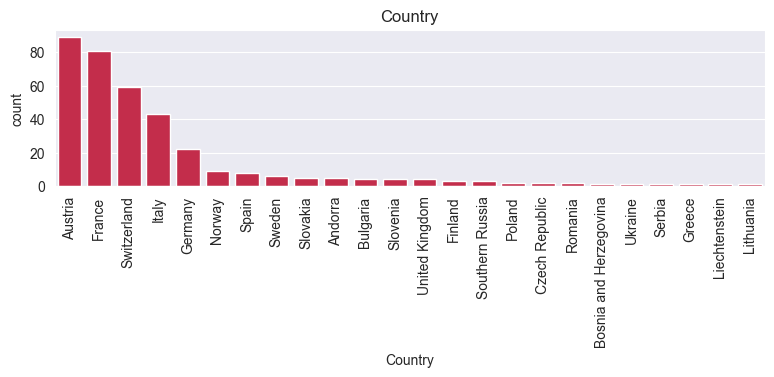

In [19]:
sns.set_style("darkgrid")

plt.figure(figsize=(8, 2.5))
sns.countplot(data=df, x='Country',color='crimson',order = df['Country'].value_counts().index)
plt.title('Country')

plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

The highest number of ski resorts are located in the Alpine countries: Austria, France, Switzerland, Italy and Germany. A significantly lower number of resorts is located in the remaining European countries.

## 3.2. Outlier detection

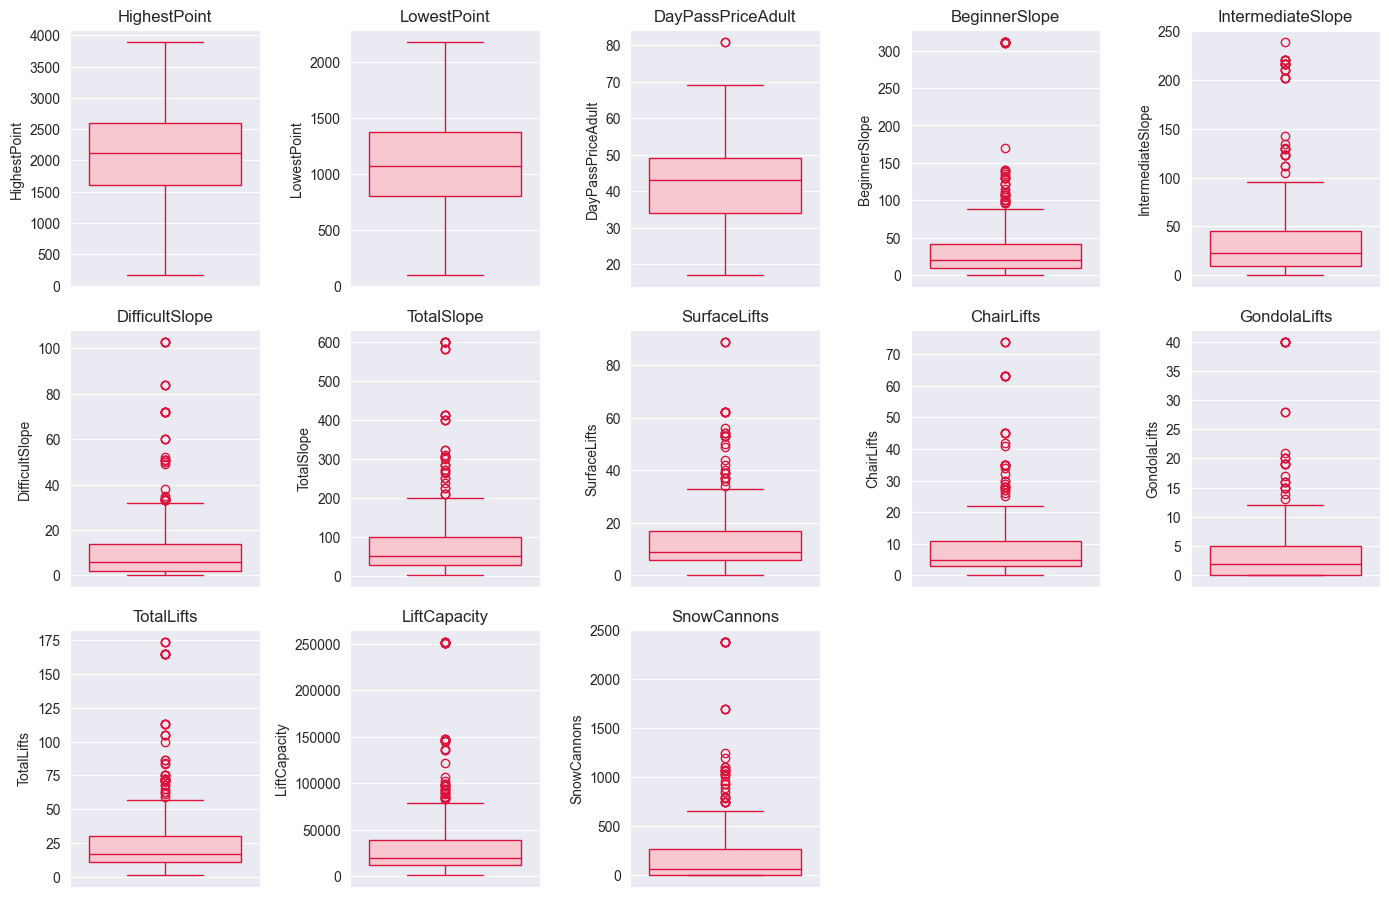

In [20]:
sns.set_style("darkgrid")

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 5, idx)
    sns.boxplot(
        data=df,
        y=feature,
        color='pink',
        boxprops=dict(edgecolor='crimson'),
        medianprops=dict(color='crimson'),
        whiskerprops=dict(color='crimson'),
        capprops=dict(color='crimson'),
        flierprops=dict(markeredgecolor='crimson')
    )
    plt.title(feature)

plt.tight_layout()
plt.show()

Boxplot analysis confirms the presence of extreme high-value outliers in the majority of the variables. 

## 3.3. Variable relationship analysis

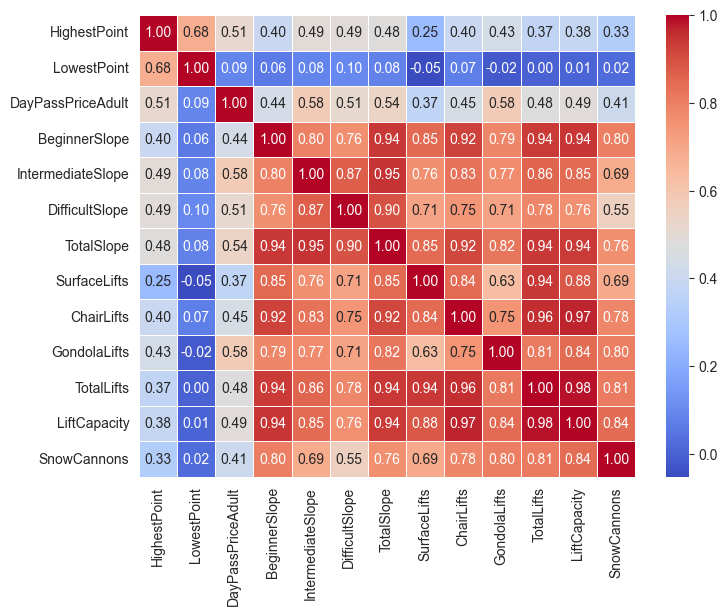

In [21]:
matrix = numerical_columns.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

**All variables, except for *LowestPoint*, are at least moderately correlated with the *DayPassPriceAdult* variable.** 
*DayPassPriceAdult* shows the strongest correlation with *IntermediateSlope* and *GondolaLifts* (0.58). A strong positive correlation (over 0.5) with *DayPassPriceAdult* can also be observed for the following variables: *TotalSlope*, *DifficultSlope* i *HighestPoint*.

Between the variables describing the length of the different types of slopes, the numbers of different types of lifts, lift capacity and the number of snow cannons **very strong positive correlations** can be observed. In most cases, the correlation coefficient exceeds 0.8. The strongest multicollinearity can be observed between the following pairs of variables: *TotalLifts* and *LiftCapacity*, and *LiftCapacity* and *ChairLifts*. **Many variables exhibit almost perfect multicollinearity.**

# 4. Data preparation

## 4.1. Logarithmic transformation

In order to mitigate the impact of extreme outliers present in the dataset, a logarithmic transformation was applied to the skewed variables. However, due to the presence of zero values in some variables, it was not possible to perform natural logarithmic transformation. Therefore, for these variables *log1p* transformation was used, which calculates natural logarithm of (X+1). For the remaining variables without zero values, the standard natural logarythm was calculated. 

In [22]:
log_cols = list(numerical_columns.columns)
log_cols.remove('DayPassPriceAdult')
log_cols.remove('HighestPoint')
log_cols.remove('LowestPoint')
log_cols

['BeginnerSlope',
 'IntermediateSlope',
 'DifficultSlope',
 'TotalSlope',
 'SurfaceLifts',
 'ChairLifts',
 'GondolaLifts',
 'TotalLifts',
 'LiftCapacity',
 'SnowCannons']

In [23]:
df_log = df.copy()
for col in log_cols:
    df_log.drop(col,axis=1,inplace=True)
    if (df[col]==0).any():
        df_log[f'log1p_{col}']=np.log1p(df[col])
    else:
        df_log[f'log_{col}']=np.log(df[col])

Distributions of the transformed variables

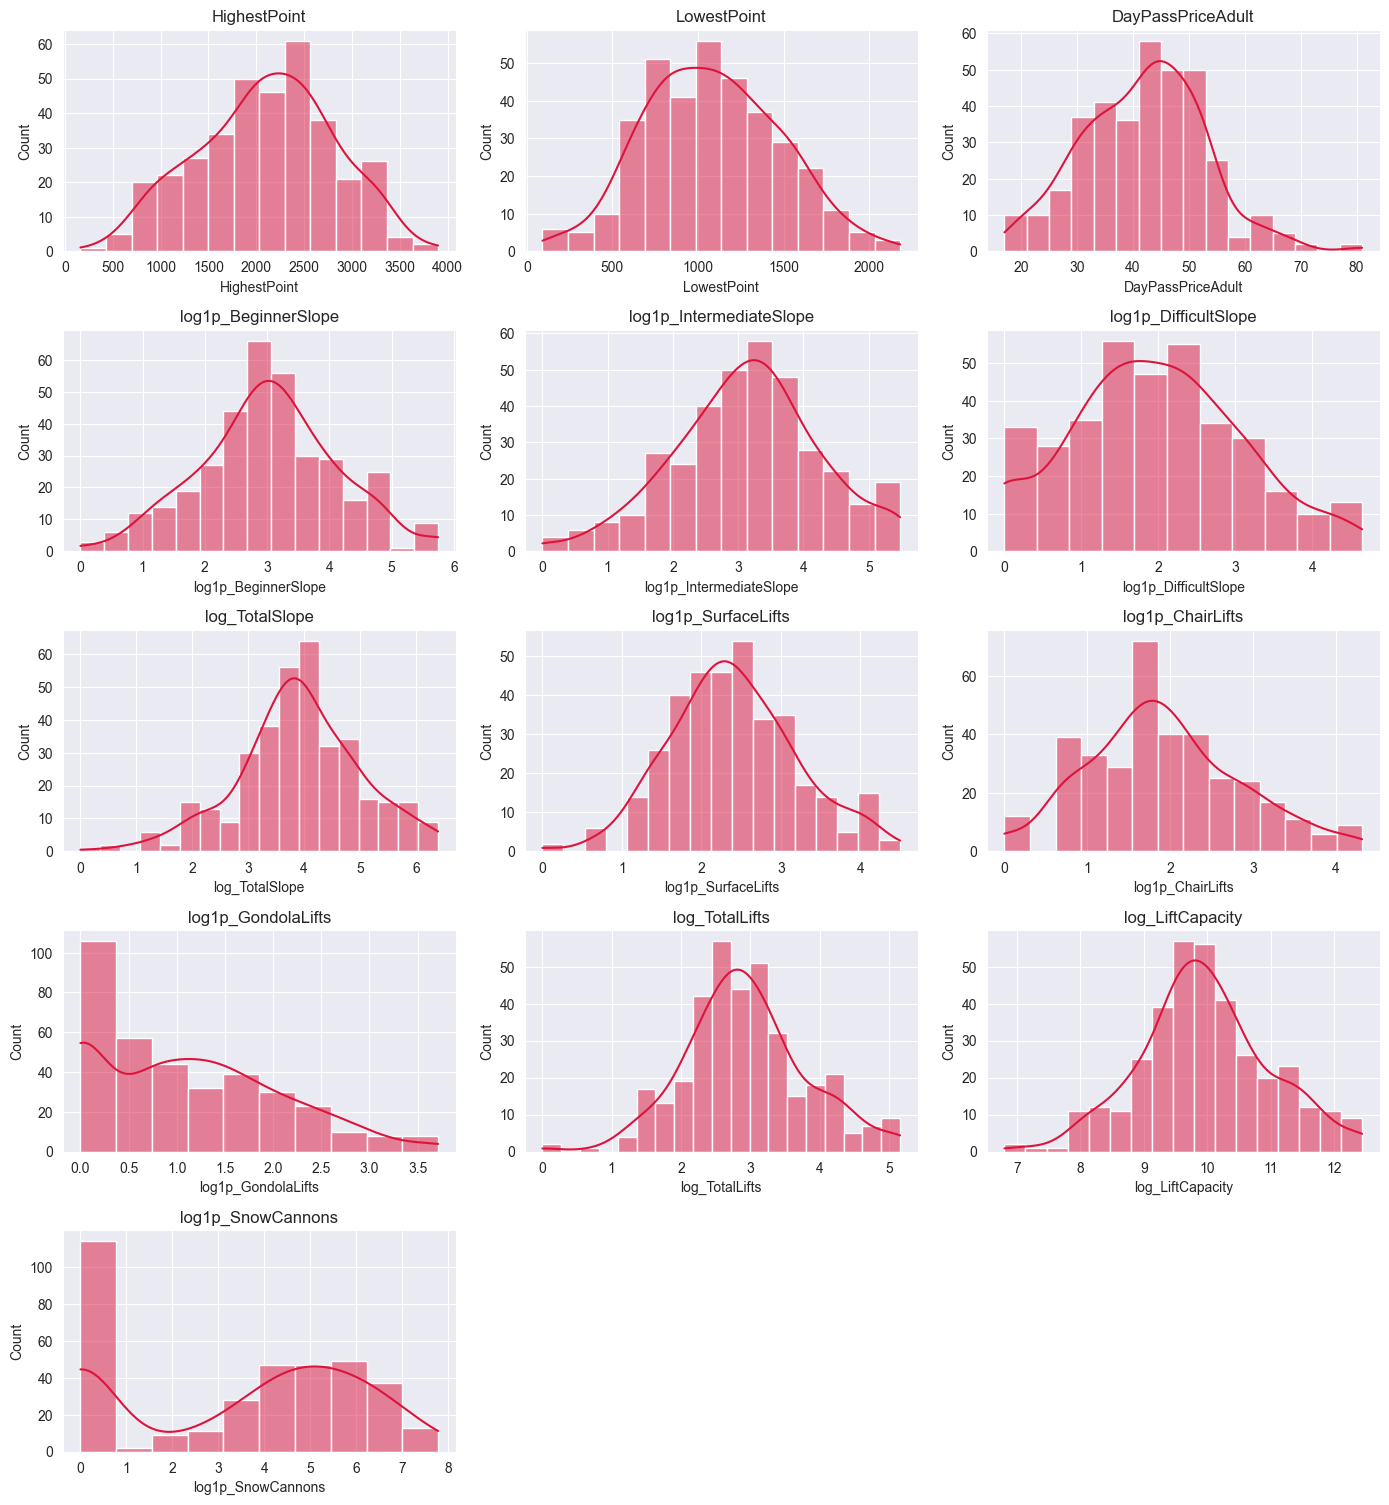

In [24]:
sns.set_style("darkgrid")

numerical_columns = df_log.select_dtypes(include=['float64','int64'])

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 3, idx)
    sns.histplot(df_log[feature], kde=True, color='crimson')
    plt.title(feature)

plt.tight_layout()
plt.show()

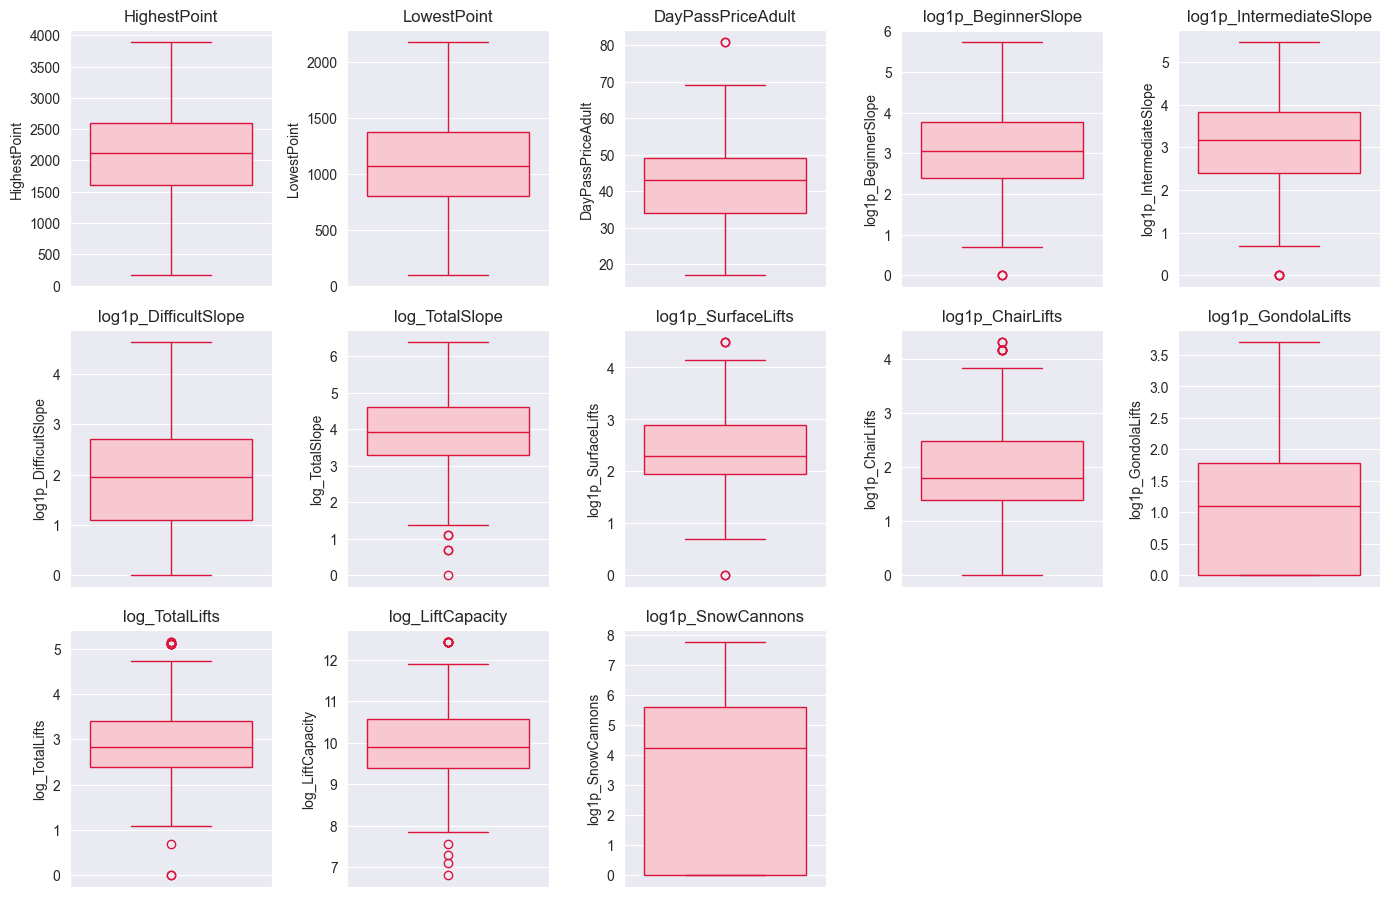

In [25]:
sns.set_style("darkgrid")

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 5, idx)
    sns.boxplot(
        data=df_log,
        y=feature,
        color='pink',
        boxprops=dict(edgecolor='crimson'),
        medianprops=dict(color='crimson'),
        whiskerprops=dict(color='crimson'),
        capprops=dict(color='crimson'),
        flierprops=dict(markeredgecolor='crimson')
    )
    plt.title(feature)

plt.tight_layout()
plt.show()

The logarithmic transformation allowed to reduce the skewness of the variable distributions and thus, mitigate the impact of outliers on the estimation. Boxplot analysis confirms the significant reduction of outliers in the dataset.

## 4.2. Multicolllinearity elimination

After applying logarithmic transformation, the strength of the correlations between variables was reassessed.

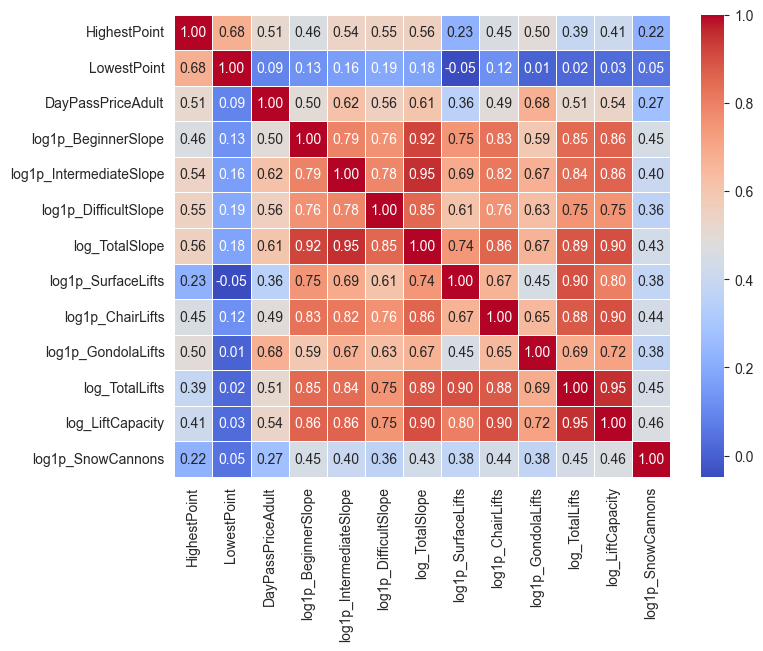

In [26]:
matrix = numerical_columns.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

After the transformation, the correlations between the majority of the variables slightly weakened. *SnowCannons* variable, previously very strongly correlated with the rest of the variables, now shows only moderate relationship with them. However, the problem of very strong, almost perfect multicollinearity is still present in the dataset. 

In order to meet the linear regression assumption, considering non-multicollinear predictors, a subset of variables was selected. Therefore, multicollinear variables were excluded from further analysis. The following variables were selected for the final dataset: *HighestPoint*, *log_TotalSlope* and *log_GondolaLifts*, based on the strength of the relationship with the *DayPassPriceAdult* and correlations between them.

In [27]:
reg_cols = ['DayPassPriceAdult','HighestPoint','log_TotalSlope','log1p_GondolaLifts']

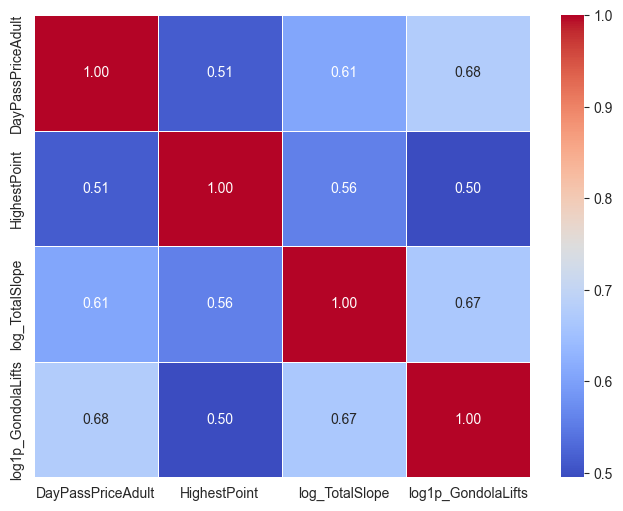

In [28]:
matrix = df_log[reg_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

In the analyzed subset of the predictors, a problem of perfect multicollinearity no longer exists. However, variables are still moderately or highly correlated (0.5-0.7)

## 4.3. Feature selection i feature engineering

*Resort* variable, including the ski resort name, was dropped from the dataset. 
On the basis of the *Country* variable, 3 new variables were created:
* *AlpineCountry* - binary variable indicating, if the resort is located in the Alpine country, 
* *PyreneanCountry* - binary variable indicating, if the resort is located in the Pyrenean country, 
* *NordicCountry* - binary variable indicating, if the resort is located in the Nordic country.  
It should be noted that a country can belong to two groups simultaneously: France is both an Alpine and a Pyrenean country.  
*Country* variable was then eliminated from the dataset.

In [29]:
df_log.drop('Resort',axis=1,inplace=True)

In [30]:
df_log['AlpineCountry']=df_log['Country'].isin(['Austria','France','Switzerland','Italy','Germany','Slovenia','Liechtenstein']).astype(int)
df_log['PyreneanCountry']=df_log['Country'].isin(['Spain','Andorra','France']).astype(int)
df_log['NordicCountry']=df_log['Country'].isin(['Sweden','Norway','Finland']).astype(int)
df_log.drop('Country',axis=1,inplace=True)

In [31]:
df_log['NightSki'] = df_log['NightSki'].map({'Yes':1,'No':0})
df_log['Snowparks'] = df_log['Snowparks'].map({'Yes':1,'No':0})

## 4.4. Train-test split (80/20)

In [32]:
X = df_log.drop('DayPassPriceAdult', axis=1)
y = df_log['DayPassPriceAdult']

X = sm.add_constant(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Modelling

***DayPassPriceAdult*** is the target variable of the regression models. 
In the further analyses, two sets of predictor variables were considered: 
* **limited set of predictors** - a subset of predictors obtained after addressing multicollinearity: *HighestPoint*, *log_TotalSlope* and *log_GondolaLifts*, *Snowparks*, *NightSki*, *AlpineCountry*, *PyreneanCountry* and *NordicCountry*.
* **full set of predictors** - consisting of all variables. The only two variables not present in this set are *log_TotalSlope* and *log_TotalLifts*, as their untransformed forms are sums of other variables and it is impossible to observe their rise while the other variables remain unchanged and therefore their coefficients could not be interpreted independently. 

Thanks to the usage of two different sets of predictors, it is possible to assess whether it is preferrable to build a model on the limited set of non-multicollinear predictors, or to use regularization estimation methods, robust to multicollinearity, such as Ridge or LASSO. A selection of $\alpha$ parameter value, controlling the strength of regularization, was performed by the cross-validation method.


## 4.1. Linear regression model - limited set of predictors

### 4.1.1. Model training

In [33]:
X_train_sub = X_train[['const','HighestPoint','log_TotalSlope','log1p_GondolaLifts','AlpineCountry','PyreneanCountry','NordicCountry','Snowparks','NightSki']]
X_test_sub = X_test[['const','HighestPoint','log_TotalSlope','log1p_GondolaLifts','AlpineCountry','PyreneanCountry','NordicCountry','Snowparks','NightSki']]

In [34]:
lr = sm.OLS(y_train, X_train_sub).fit()

In [35]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      DayPassPriceAdult   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     65.42
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           2.40e-59
Time:                        12:18:10   Log-Likelihood:                -929.87
No. Observations:                 285   AIC:                             1878.
Df Residuals:                     276   BIC:                             1911.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 15.0400      1.900      7.917      0.000      11.300      18.780
HighestPoint           0.0041      0.001      5.580      0.000       0.003       0.006
log_TotalSlope         2.3305      0.549      4.241      0.000       1.249       3.412
log1p_GondolaLifts     4.5385      0.591      7.685      0.000       3.376       5.701
AlpineCountry          4.7651      1.259      3.786      0.000       2.287       7.243
PyreneanCountry       -6.2635      0.998     -6.279      0.000      -8.227      -4.300
NordicCountry         13.7753      2.259      6.098      0.000       9.329      18.222
Snowparks              2.0959      0.982      2.135      0.034       0.163       4.028
NightSki              -1.6747      0.827     -2.025      0.044      -3.303      -0.046
==============================================================================
Omnibus:                       15.107   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               39.697
Skew:                           0.022   Prob(JB):                     2.40e-09
Kurtosis:                       4.828   Cond. No.                     1.47e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.47e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

All coefficients are statistically significant ($\alpha$=0.05).

In [36]:
lr_coef = lr.params

In [37]:
y_pred_lr = lr.predict(X_test_sub)
y_pred_train_lr = lr.predict(X_train_sub)

### 4.1.2. Model evaluation

In [38]:
rmse_train_lr = root_mean_squared_error(y_train, y_pred_train_lr)
mae_train_lr = mean_absolute_error(y_train, y_pred_train_lr)
r2_train_lr = r2_score(y_train, y_pred_train_lr)

In [39]:
rmse_test_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_test_lr = mean_absolute_error(y_test, y_pred_lr)
r2_test_lr = r2_score(y_test, y_pred_lr)

In [40]:
print("RMSE train: ",round(rmse_train_lr,2))
print("MAE train: ",round(mae_train_lr,2))
print("R2 train: ",round(r2_train_lr,2))

RMSE train:  6.32
MAE train:  4.79
R2 train:  0.65


In [41]:
print("RMSE test: ",round(rmse_test_lr,2))
print("MAE test: ",round(mae_test_lr,2))
print("R2 test: ",round(r2_test_lr,2))

RMSE test:  6.83
MAE test:  5.31
R2 test:  0.61


The linear regression model achieved an $R^2$ of 0.65 on the train and 0.61 on the test dataset. RMSE and MAE have only slightly higher values on the test dataset, indicating that there are no clear signs of overfitting. All coefficients of the model are statistically significant at $\alpha$=0.05. 

## 4.2. Ridge regression - limited set of predictors

Models with regularization require variable standarization, because the penalty term is based on the value of the coefficients. Therefore, for Ridge and LASSO regression models sets of standardized predictors were used.

### 4.2.1. Model training

In [42]:
X_train_sub.drop('const',axis=1,inplace=True)
X_test_sub.drop('const',axis=1,inplace=True)

C:\Users\Malgorzata\AppData\Local\Temp\ipykernel_18568\1172008397.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sub.drop('const',axis=1,inplace=True)
C:\Users\Malgorzata\AppData\Local\Temp\ipykernel_18568\1172008397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_sub.drop('const',axis=1,inplace=True)


In [43]:
scaler = StandardScaler()
X_train_sub_scaled = X_train_sub.copy()
X_test_sub_scaled = X_test_sub.copy()
num_cols_sub = ['HighestPoint','log_TotalSlope','log1p_GondolaLifts']
X_train_sub_scaled[num_cols_sub] = scaler.fit_transform(X_train_sub[num_cols_sub])
X_test_sub_scaled[num_cols_sub] = scaler.transform(X_test_sub[num_cols_sub])

In [44]:
alphas = [0.1, 1, 10]
ridge_cv = RidgeCV(alphas, cv=5)

In [45]:
ridge_cv.fit(X_train_sub_scaled, y_train)
ridge_cv.alpha_

np.float64(1.0)

In [46]:
limited_cols = X_train_sub.columns

In [47]:
ridge_coef = ridge_cv.coef_

In [48]:
ridge_intercept = ridge_cv.intercept_

In [49]:
y_pred_ridge = ridge_cv.predict(X_test_sub_scaled)
y_pred_train_ridge = ridge_cv.predict(X_train_sub_scaled)

### 4.2.2. Model evaluation

In [50]:
rmse_train_ridge = root_mean_squared_error(y_train, y_pred_train_ridge)
mae_train_ridge = mean_absolute_error(y_train, y_pred_train_ridge)
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)

In [51]:
rmse_test_ridge = root_mean_squared_error(y_test, y_pred_ridge)
mae_test_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_test_ridge = r2_score(y_test, y_pred_ridge)

In [52]:
print("RMSE train: ",round(rmse_train_ridge,2))
print("MAE train: ",round(mae_train_ridge,2))
print("R2 train: ",round(r2_train_ridge,2))

RMSE train:  6.33
MAE train:  4.79
R2 train:  0.65


In [53]:
print("RMSE test: ",round(rmse_test_ridge,2))
print("MAE test: ",round(mae_test_ridge,2))
print("R2 test: ",round(r2_test_ridge,2))

RMSE test:  6.8
MAE test:  5.3
R2 test:  0.61


The Ridge regression model achieved an $R^2$ of 0.65 on the train and 0.62 on the test dataset - almost the same results as the linear regression model. RMSE and MAE values are also almost identical to the linear regression errors, with no indication of model overfitting.

## 4.3. LASSO regression - limited set of predictors

### 4.3.1. Model training

In [54]:
alphas = [0.1, 1, 10]
lasso_cv = LassoCV(alphas=alphas, cv=5)

In [55]:
lasso_cv.fit(X_train_sub_scaled, y_train)
lasso_cv.alpha_

np.float64(0.1)

In [56]:
lasso_coef = lasso_cv.coef_

In [57]:
lasso_intercept = lasso_cv.intercept_

In [58]:
y_pred_lasso = lasso_cv.predict(X_test_sub_scaled)
y_pred_train_lasso = lasso_cv.predict(X_train_sub_scaled)

### 4.3.2. Model evaluation

In [59]:
rmse_train_lasso = root_mean_squared_error(y_train, y_pred_train_lasso)
mae_train_lasso = mean_absolute_error(y_train, y_pred_train_lasso)
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)

In [60]:
rmse_test_lasso = root_mean_squared_error(y_test, y_pred_lasso)
mae_test_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_test_lasso = r2_score(y_test, y_pred_lasso)

In [61]:
print("RMSE train: ",round(rmse_train_lasso,2))
print("MAE train: ",round(mae_train_lasso,2))
print("R2 train: ",round(r2_train_lasso,2))

RMSE train:  6.38
MAE train:  4.83
R2 train:  0.65


In [62]:
print("RMSE test: ",round(rmse_test_lasso,2))
print("MAE test: ",round(mae_test_lasso,2))
print("R2 test: ",round(r2_test_lasso,2))

RMSE test:  6.74
MAE test:  5.32
R2 test:  0.62


Once again, the LASSO regression model achieved almost identical results to linear and Ridge regression model - with moderate model fitness and no indication of model overfitting. 

## 4.4. Ridge regression - full set of predictors

### 4.4.1. Model training

In [63]:
X_train_full = X_train.drop('log_TotalLifts',axis=1)
X_train_full.drop('log_TotalSlope',axis=1,inplace=True)

X_test_full = X_test.drop('log_TotalLifts',axis=1)
X_test_full.drop('log_TotalSlope',axis=1,inplace=True)

In [64]:
scaler_full = StandardScaler()

X_train_full_scaled = X_train_full.copy()
X_test_full_scaled = X_test_full.copy()
num_cols_full = ['HighestPoint', 'LowestPoint',
       'log1p_BeginnerSlope', 'log1p_IntermediateSlope',
       'log1p_DifficultSlope', 'log1p_SurfaceLifts', 'log1p_ChairLifts',
       'log1p_GondolaLifts', 'log_LiftCapacity', 'log1p_SnowCannons']
X_train_full_scaled[num_cols_full] = scaler_full.fit_transform(X_train_full[num_cols_full])
X_test_full_scaled[num_cols_full] = scaler_full.transform(X_test_full[num_cols_full])

In [65]:
alphas = [0.1, 1, 10]
ridge_cv_full = RidgeCV(alphas, cv=5)
ridge_cv_full.fit(X_train_full_scaled, y_train)
ridge_cv_full.alpha_

np.float64(1.0)

In [66]:
ridge_full_coef = ridge_cv_full.coef_
ridge_full_intercept = ridge_cv_full.intercept_

In [67]:
y_pred_ridge_full = ridge_cv_full.predict(X_test_full_scaled)
y_pred_train_ridge_full = ridge_cv_full.predict(X_train_full_scaled)

### 4.4.2. Model evaluation

In [68]:
rmse_train_ridge_full = root_mean_squared_error(y_train, y_pred_train_ridge_full)
mae_train_ridge_full = mean_absolute_error(y_train, y_pred_train_ridge_full)
r2_train_ridge_full = r2_score(y_train, y_pred_train_ridge_full)
rmse_test_ridge_full = root_mean_squared_error(y_test, y_pred_ridge_full)
mae_test_ridge_full = mean_absolute_error(y_test, y_pred_ridge_full)
r2_test_ridge_full = r2_score(y_test, y_pred_ridge_full)

In [69]:
print("RMSE train: ",round(rmse_train_ridge_full,2))
print("MAE train: ",round(mae_train_ridge_full,2))
print("R2 train: ",round(r2_train_ridge_full,2))

RMSE train:  6.25
MAE train:  4.75
R2 train:  0.66


In [70]:
print("RMSE test: ",round(rmse_test_ridge_full,2))
print("MAE test: ",round(mae_test_ridge_full,2))
print("R2 test: ",round(r2_test_ridge_full,2))

RMSE test:  6.81
MAE test:  5.13
R2 test:  0.61


Once again, the results of the model are almost identical to the previously estimated models.

## 4.5. LASSO regression - full set of predictors

### 4.5.1. Model training

In [71]:
alphas = [0.1, 1, 10]
lasso_cv_full = LassoCV(alphas=alphas, cv=5)
lasso_cv_full.fit(X_train_full_scaled, y_train)
lasso_cv_full.alpha_

np.float64(0.1)

In [72]:
lasso_full_coef = lasso_cv_full.coef_
lasso_full_intercept = lasso_cv_full.intercept_

In [73]:
y_pred_lasso_full = lasso_cv_full.predict(X_test_full_scaled)
y_pred_train_lasso_full = lasso_cv_full.predict(X_train_full_scaled)

### 4.5.2. Model evaluation

In [74]:
rmse_train_lasso_full = root_mean_squared_error(y_train, y_pred_train_lasso_full)
mae_train_lasso_full = mean_absolute_error(y_train, y_pred_train_lasso_full)
r2_train_lasso_full = r2_score(y_train, y_pred_train_lasso_full)
rmse_test_lasso_full = root_mean_squared_error(y_test, y_pred_lasso_full)
mae_test_lasso_full = mean_absolute_error(y_test, y_pred_lasso_full)
r2_test_lasso_full = r2_score(y_test, y_pred_lasso_full)

In [75]:
print("RMSE train: ",round(rmse_train_lasso_full,2))
print("MAE train: ",round(mae_train_lasso_full,2))
print("R2 train: ",round(r2_train_lasso_full,2))

RMSE train:  6.32
MAE train:  4.8
R2 train:  0.65


In [76]:
print("RMSE test: ",round(rmse_test_lasso_full,2))
print("MAE test: ",round(mae_test_lasso_full,2))
print("R2 test: ",round(r2_test_lasso_full,2))

RMSE test:  6.76
MAE test:  5.22
R2 test:  0.62


The LASSO model achieved almost identical results to all the previous models.

# 5. Results comparison

## 5.1. Comparison of the metrics

In [77]:
results_df = pd.DataFrame(
    {
        "rmse_train":[rmse_train_lr, rmse_train_ridge, rmse_train_lasso,rmse_train_ridge_full,rmse_train_lasso_full],
        "mae_train":[mae_train_lr, mae_train_ridge, mae_train_lasso,mae_train_ridge_full,mae_train_lasso_full],
        "r2_train":[r2_train_lr, r2_train_ridge, r2_train_lasso,r2_train_ridge_full,r2_train_lasso_full],
        "rmse_test":[rmse_test_lr, rmse_test_ridge, rmse_test_lasso,rmse_test_ridge_full,rmse_test_lasso_full],
        "mae_test":[mae_test_lr, mae_test_ridge, mae_test_lasso,mae_test_ridge_full,mae_test_lasso_full],
        "r2_test":[r2_test_lr, r2_test_ridge, r2_test_lasso,r2_test_ridge_full,r2_test_lasso_full],
    },
    index=['LR','Ridge','LASSO','Ridge_full','LASSO_full']
)

In [78]:
results_df.sort_values(by='rmse_test')

,rmse_train,mae_train,r2_train,rmse_test,mae_test,r2_test
LASSO,6.379077,4.833206,0.648261,6.742304,5.320321,0.621542
LASSO_full,6.318869,4.802374,0.654870,6.763671,5.215905,0.619140
Ridge,6.326336,4.794957,0.654054,6.800347,5.297319,0.614998
Ridge_full,6.245787,4.750221,0.662807,6.813562,5.128058,0.613500
LR,6.320202,4.789978,0.654724,6.833285,5.307329,0.611259


All 5 of the estimated models performed very similarly. The models make prediction errors (RMSE) around 6.3 euros on the train and 6.8 on the test dataset (while a mean skipass price is 42 euros). Models explain approximately 60% of the variation of the skipass prices. Metrics' values vary only slightly between the train and the test dataset which suggests that there is no indication of model overfitting.

The best-performing model on the test dataset is the LASSO model estimated on the limited set of predictors. It achieved the lowest RMSE and the highest $R^2$ on the test dataset. On the other hand, on the model best fit to the train dataset was the Ridge model estimated on the full set of predictors. It is worth noting though that the differences between the models' performances were almost negligible.

The results demonstrate the effectiveness of the regularization regression models for estimation in the face of severe multicollinearity. **The LASSO model, estimated on the limited set of predictors, was selected as the final model, due to its best performance on the test dataset and better interpretability (LASSO performs feature selection, while Ridge does not).**

# 6. The final model

## 6.1. Model interpretation

In [79]:
lasso_coef = pd.DataFrame(lasso_coef, index=X_train_sub.columns)
lasso_coef.loc['const']=lasso_intercept
lasso_coef.columns=['coef']
lasso_coef

,coef
HighestPoint,2.670573
log_TotalSlope,2.680748
log1p_GondolaLifts,4.210864
AlpineCountry,3.055690
PyreneanCountry,-5.862265
NordicCountry,9.577891
Snowparks,1.726874
NightSki,-1.120961
const,39.344333


In [80]:
lasso_coef['abs_coef']=np.abs(lasso_coef['coef'])
lasso_coef[lasso_coef['coef']!=0].sort_values(by='abs_coef',ascending=False)['coef'].round(4)

const                 39.3443
NordicCountry          9.5779
PyreneanCountry       -5.8623
log1p_GondolaLifts     4.2109
AlpineCountry          3.0557
log_TotalSlope         2.6807
HighestPoint           2.6706
Snowparks              1.7269
NightSki              -1.1210
Name: coef, dtype: float64

When interpreting the model coefficients, it is crucial to remember that for the *GondolaLifts* variable the *log1p* transformation was used instead of the standard logarithmic transformation. Therefore the provided interpretation of its coefficient is fully valid only when the values of the variable are relatively high. Moreover, as the numerical predictors were standardized, their coefficients refer to the change of one standard deviation of the variable.

The LASSO method allows to perform feature selection by shrinking some coefficients to zero. However, in this case no variable was excluded from the model (no coefficient equals 0). 

* Ski pass prices in the Nordic countries are, on average, €9.58 higher than those in other countries, with other variables held constant. 
* Ski pass prices in the Alpine countries are, on average, €3.06 higher than those in other countries, with other variables held constant. 
* However, ski pass prices in the Pyrenean countries are, on average, €5.86 lower than those in other countries, with other variables held constant. 
* Resorts offering night skiiing have, on average, €1.12 lower ski pass prices than other resorts, with other variables held constant. 
* Ski pass prices in the resorts which offer ski parks are, on average, €1.73 higher than in other resorts, with other variables held constant.
* A one standard deviation rise of the altitude of the highest point in the resort is associated with a €2.67 rise of ski pass price.
* A one standard deviation rise of the logarithm of the total slope length is associated with a €2.68 rise of ski pass price.
* A one standard deviation rise of the logarithm (*log1p*) of the number of gondola lifts is associated with a €4.21 rise of ski pass price.

## 6.2. SHAP Profiles

### Individual profiles

SHAP profiles allow to analyze how each variable contributed to the prediction made by the model. In this section, SHAP profiles for 3 different ski resorts were demonstrated: 
* Bialka Tatrzanska - local (Polish) resort, with relatively low prices,
* Verbier 4 Vallees - ski resort in the Swiss Alps, one of the biggest resorts in the world, known for its very high prices,
* Arcalis-Ordino - located in the Pyrenees, with moderate ski pass prices.

In [81]:
explainer = shap.LinearExplainer(lasso_cv, X_train_sub_scaled)
shap_values = explainer(X_test_sub_scaled)
shap.initjs()

In [82]:
shap_values.feature_names = X_test_sub.columns.tolist()
shap_values.data = X_test_sub.values

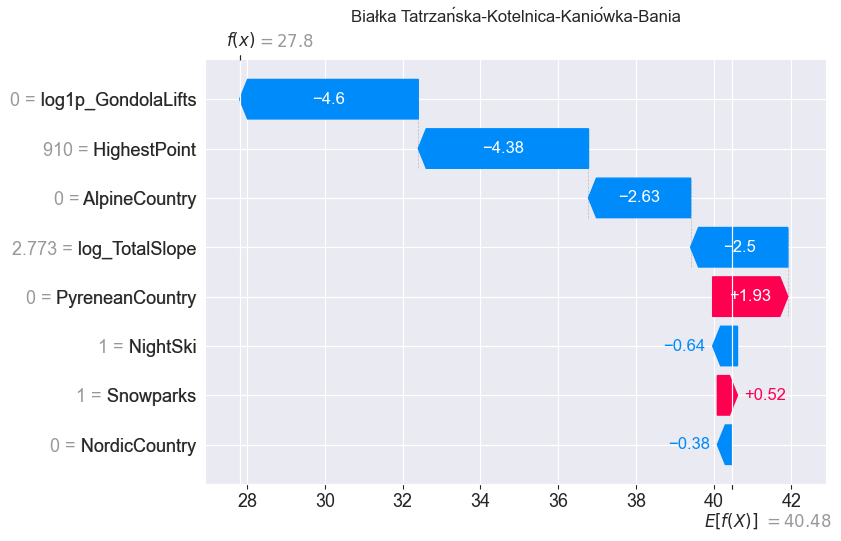

In [83]:
i = 47
shap.waterfall_plot(shap_values[i], show=False)
plt.title(df.loc[X_test.index[i]]['Resort'])
plt.show()

The presented SHAP profile shows how, for the Bialka Tatrzanska resort, **a ski pass price of €27.8** was predicted. The strongest negative contribution (-€4.6) to the prediction can be attributed to the **lack of gondola lifts in the resort**. A **highest point of the resort located on 910 m** lowers the price by €4.38. A **total length of slopes** (its log_value  = 2.8, total length = 16 km) also negatively contributes to the price (-€2.5). On the other hand, a predicted price is increased because of **the snow park** in the resort (€0.52) and the fact, that the resort is not located in the Pyrenees (€1.93). The final ski pass price prediction equals €27.8, which is way below the mean value of €41.9. 

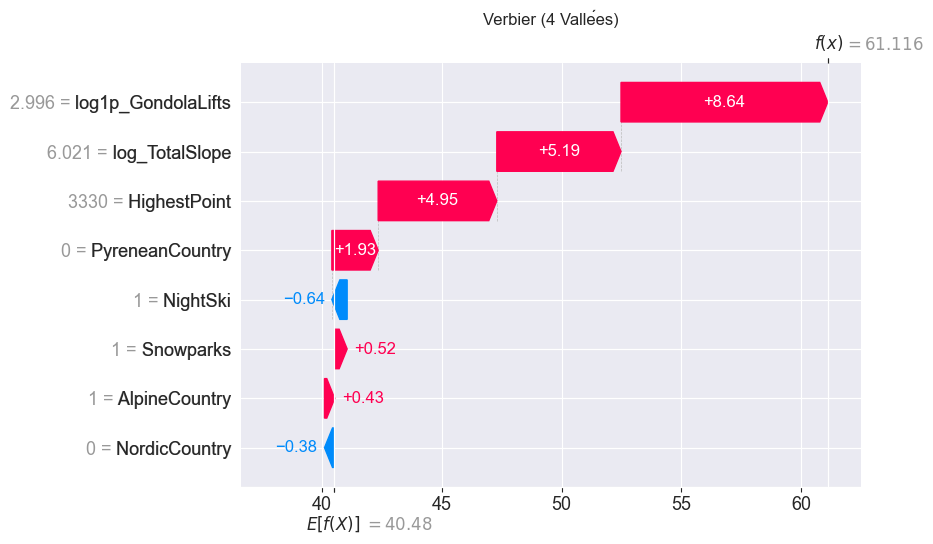

In [120]:
i = 3
shap.waterfall_plot(shap_values[i], show=False)
plt.title(df.loc[X_test.index[i]]['Resort'])
plt.show()

The presented SHAP profile shows how the ski pass price prediction of €61.12 was obtained for the Verbier 4 Vallees resort. Almost every resort feature positively impacts the ski pass price. The highest contribution (€8.64) can be attributed to the **high number of gondola lifts** in the resort (log1p value = 3, number of lifts = 19) and an **extremely high total length of slopes** (€5.19. log value = 6, total length = 412 km). A high **location over 3,300m** also increases the price (€4.95). A much smaller positive contribution can be attributed to the resort's Alpine location (€0.43) and presence of snowparks (€0.52). The only features negatively contributing to the price are nightskiing (-€0.64) and location outside of Nordic countries (-€0.38). The final ski pass price prediction of €61.12 is very high, reflecting the resort's luxurious profile. 

In [122]:
df[df['Resort'].str.contains('Verbier')]

,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
318,Verbier (4 Vallées),Switzerland,3330,821,66,107,202,103,412,Yes,Yes,39,17,19,75,85022,0


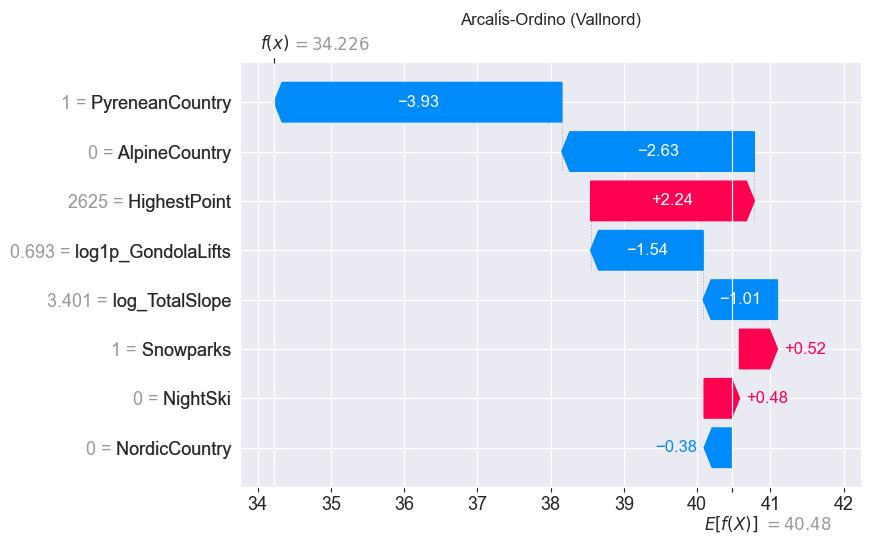

In [85]:
i = 66
shap.waterfall_plot(shap_values[i], show=False)
plt.title(df.loc[X_test.index[i]]['Resort'])
plt.show()

The presented SHAP profile shows how the **ski pass price prediction of €34.23** was obtained for the Arcalis-Ordino resort. The highest negative contribution (-€3.93) can be attributed to the resort's **location in the Pyrenees**. Moreover, the feature of not being located in the Alps lowered the predicted price by €2.63. The **low number of gondola lifts** (only 1) and **relatively small total length of slopes** (its log value = 3.4, total length = 30 km) also negatively impact the price. On the other hand, a positive contribution to the ski pass price can be attributed to the resort's high location, at over 2,600m (€2.24), presence of a snow park (€0.52) and lack of night skiing (€0.48). The final ski pass price prediction equals €34.23, which is below the mean value of €41.9. 

# Summary

The purpose of the project was to build **a regression model predicting skipass prices in European ski resorts** based on the resort's characteristics, such as e.g. highest point altitude, length of ski slopes, number of lifts and its location. The dataset used in the analysis exhibited **strong, and in some cases almost perfect multicollinearity**, which violated the assumptions of valid OLS model estimation. Therefore, as part of the project, performances of **regularization methods (Ridge and LASSO)** were compared to the performance of a standard OLS method, in the face of strong multicollinearity. Moreover, models were trained using two different sets of predictors, which allowed for a more comprehensive assessment of the regularization methods.  

Each of the trained models performed very similarly, **explaining approximately 60% of the ski pass price variation**. The models made p**rediction errors (RMSE) around €6.3 on the train and €6.8 on the test** dataset (while a mean skipass price is €42).  
The final best-performing model was the **LASSO model**, estimated on the limited set of predictors. However, it should be noted that the differences between the models' performances were almost negligible.  

In the final LASSO regression model the problem of multicollinearity was addressed through two approaches. Firstly, only a subset of explaining variables was chosen, in order to eliminate the pairs of almost perfectly correlated variables. That approach allowed to weaken the strength of multicollinearity in the dataset, but did not completely mitigate the problem. Therefore, in the estimation process a regularization method was used, which allowed to shrink the coefficients towards zero and make their estimation more stable.  

The interpretation of the final model allowed to assess the impact of each variable on the ski pass price in the resort. Some of the relationships (with other variables held constant) include: 
* Ski pass prices are, on average, **€9.58 higher in the Nordic countries, €3.06 higher in the Alpine countries and €5.86 lower in the Pyreneean countries**, than those in remaining countries. 
* Ski pass prices in the resorts which offer **ski parks** are, on average, **€1.73 higher**. On the other hand, resorts offering **night skiiing** have, on average, **€1.12 lower** ski pass prices than other resorts. 
* A one standard deviation rise of the altitude of the highest point in the resort is associated with a €2.67 rise of ski pass price.

Finally, SHAP profiles for 3 selected ski resorts were presented. The analysis of the profiles allowed to identify the features which contribute to e.g. extremely high prices in the Swiss Verbier 4 Vallees resort or relatively low prices in the local Polish resort in Bialka Tatrzanska.  

The estimated regression model may be valuable in various different application. 
* Firstly, it can allow to **assess an appropriate price for the potential new ski resorts** in Europe, based on their characteristics. 
* Secondly, it allows to **estimate a suitable price shift** when changes in the existing ski resorts are introduced. For example, the resort's management can assess if a construction of a new gondola lift would be profitable, by comparing its cost to the potential income from the increased ski pass prices. 
* Lastly, the model, especially presented with the SHAP profiles, allows the customers to **understand and compare the prices** of the ski resorts and select the ski pass most suitable for their needs.